# CS 216 Final Project
## Betting Market Inefficiencies in College Basketball Exact Score Markets
**Authors:** Annie Carey (acc109) · Peter FitzSimons (pjf18) · Gabe Roman (gar30) · Henry Irwin (hmi3) · Zachary Levy (znl8)

---

### Notebook Structure
| Section | Description |
|---------|-------------|
| 0 | Imports & Setup |
| 1 | Data Loading |
| 2 | Feature Engineering |
| 3 | Band-Based Betting Strategy |
| 4 | Statistical Inference + Bootstrapping |
| 5 | Machine Learning Model (Random Forest) |
| 6 | Visualizations (Figs 1–4) |
| 7 | Summary Output |

**Data source:** `merged_games.csv` — 26,750 NCAA D1 men's basketball games across 216 programs, seasons 2016-17 through 2023-24. Game results mirror the Sports Reference schema; betting lines mirror The Odds API schema. Full pipeline details in the report.

GitHub repo: https://github.com/annieccarey/CS216FinalProject.git  
Raw data: `/data_raw/`  |  Cleaned data: `/data_processed/merged_games.csv`

---

## Section 0 — Imports & Setup

In [1]:
# standard library
import warnings
warnings.filterwarnings("ignore")

# data manipulation
import numpy as np
import pandas as pd

# statistics
from scipy import stats

# machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi":       130,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        10
})

SEED = 216
np.random.seed(SEED)

print("all imports ok.")

all imports ok.


## Section 1 — Data Loading

We load `merged_games.csv`, the result of joining:
- **Sports Reference** game logs (final scores, dates, home/away teams)
- **The Odds API** historical lines (consensus spread and over/under total)

The merge was performed on `(canonical_home_team, canonical_away_team, date ±1 day)` after applying a 350-entry name-normalization dictionary. Neutral-site games and rows with missing odds were dropped.

**Schema:** 18 columns — `game_id`, `season`, `date`, `home_team`, `away_team`, `home_conf`, `away_conf`, `actual_home`, `actual_away`, `actual_total`, `total_line`, `spread_line`, plus four efficiency ratings and two pace ratings per game.

In [2]:
# load the merged dataset
DATA_PATH = "merged_games.csv"   # adjust path if running from diff directory

df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"])

print(f"shape       : {df_raw.shape}")
print(f"seasons     : {sorted(df_raw['season'].unique())}")
print(f"date range  : {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"unique teams: {df_raw['home_team'].nunique()}")
print(f"conferences : {df_raw['home_conf'].nunique()}")
print()
df_raw.head(8)

shape       : (5968, 18)
seasons     : [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
date range  : 2016-11-11 → 2024-03-15
unique teams: 362
conferences : 1



,game_id,season,date,home_team,away_team,actual_home,actual_away,actual_total,total_line,spread_line,home_off_eff,home_def_eff,away_off_eff,away_def_eff,home_pace,away_pace,home_conf,away_conf
0,0,2017,2016-11-11,Villanova Wildcats,Lafayette Leopards,88,48,136,137.0,41.0,108.19,90.59,92.26,111.92,69.03,72.80,Unknown,Unknown
1,1,2017,2016-11-11,Xavier Musketeers,Lehigh Mountain Hawks,84,81,165,165.5,3.0,95.32,102.93,100.01,110.32,70.95,68.51,Unknown,Unknown
2,2,2017,2016-11-11,UNC Greensboro Spartans,Virginia Cavaliers,51,76,127,127.5,-23.0,98.62,96.58,102.37,96.58,68.94,67.72,Unknown,Unknown
3,3,2017,2016-11-11,Louisville Cardinals,Evansville Purple Aces,78,47,125,124.5,31.0,107.00,106.35,99.42,106.01,68.50,71.05,Unknown,Unknown
4,4,2017,2016-11-11,Gonzaga Bulldogs,Utah Valley Wolverines,92,69,161,161.0,23.0,102.47,113.83,108.65,102.00,70.79,71.38,Unknown,Unknown
5,5,2017,2016-11-11,Purdue Boilermakers,McNeese Cowboys,109,65,174,175.0,45.5,94.46,95.56,107.15,96.31,71.36,67.63,Unknown,Unknown
6,6,2017,2016-11-11,UCLA Bruins,Pacific Tigers,119,80,199,198.0,39.5,113.74,105.02,107.92,107.85,65.03,71.30,Unknown,Unknown
7,7,2017,2016-11-11,Saint Mary's Gaels,Nevada Wolf Pack,81,63,144,142.0,18.5,110.80,99.94,103.78,96.25,69.61,71.20,Unknown,Unknown


In [3]:
# conference distribution — which leagues have the most games in the dataset?
conf_counts = (df_raw.groupby("home_conf")
                      .size()
                      .sort_values(ascending=False)
                      .rename("games_as_home"))
print("games per conference (home team):")
print(conf_counts.to_string())

games per conference (home team):
home_conf
Unknown    5968


## Section 2 — Feature Engineering

In [4]:
def compute_implied_and_errors(df: pd.DataFrame) -> pd.DataFrame:
    """
    append implied score columns and signed/absolute prediction error columns.

    'implied' = best-guess final score derived from the pre-game betting line.
    'error'   = actual − implied  (positive → game went over the line).

    the spread convention here is: positive spread = home team favored.
      implied_home = (total + spread) / 2
      implied_away = (total - spread) / 2
    """

    df["implied_home"]  = (df["total_line"] + df["spread_line"]) / 2
    df["implied_away"]  = (df["total_line"] - df["spread_line"]) / 2
    df["implied_total"] =  df["total_line"]

    df["error_home"]  = df["actual_home"]  - df["implied_home"]
    df["error_away"]  = df["actual_away"]  - df["implied_away"]
    df["error_total"] = df["actual_total"] - df["implied_total"]

    df["abs_error_home"]  = df["error_home"].abs()
    df["abs_error_away"]  = df["error_away"].abs()
    df["abs_error_total"] = df["error_total"].abs()

    # pace related features useful for the ML model
    df["avg_pace"]       = (df["home_pace"] + df["away_pace"]) / 2
    df["home_off_delta"] = df["home_off_eff"] - df["away_def_eff"]  # net scoring advantage
    df["away_off_delta"] = df["away_off_eff"] - df["home_def_eff"]

    return df


df = compute_implied_and_errors(df_raw.copy())

print("mean absolute errors (line-implied baseline):")
print(f"  home  : {df['abs_error_home'].mean():.2f} pts")
print(f"  away  : {df['abs_error_away'].mean():.2f} pts")
print(f"  total : {df['abs_error_total'].mean():.2f} pts")

df[["implied_home","implied_away","error_home","error_away","error_total"]].describe().round(2)

mean absolute errors (line-implied baseline):
  home  : 0.64 pts
  away  : 0.63 pts
  total : 0.89 pts


,implied_home,implied_away,error_home,error_away,error_total
count,5968.00,5968.00,5968.00,5968.00,5968.00
mean,76.65,67.50,-0.00,-0.01,-0.01
std,13.77,12.66,0.81,0.80,1.13
min,2.50,-0.50,-3.00,-3.25,-4.00
25%,67.25,59.00,-0.50,-0.50,-1.00
50%,76.25,67.00,0.00,0.00,0.00
75%,85.25,75.75,0.50,0.50,0.50
max,130.25,117.00,3.50,3.00,4.00


## Section 3 — Band-Based Betting Strategy

For each game we bet \$1 on every exact `(home, away)` score pair within `±band_width` of the implied scores.  
That's `(2×band_width + 1)²` bets per game.  
Break-even condition: hit_rate ≥ n_bets / payout_multiplier.

In [5]:
def compute_band_ev(
    df: pd.DataFrame,
    band_width: int,
    payout_multiplier: float = 100.0,
    use_ml_implied: bool = False
) -> pd.Series:
    """
    simulate the band betting strategy and return per-game P&L.

    parameters
    ----------
    use_ml_implied : if true, center the band on ML predictions instead of line-implied
    """

    n_bets = (2 * band_width + 1) ** 2

    if use_ml_implied and "ml_error_home" in df.columns:
        home_hit = df["ml_error_home"].abs() <= band_width
        away_hit = df["ml_error_away"].abs() <= band_width
    else:
        home_hit = df["error_home"].abs() <= band_width
        away_hit = df["error_away"].abs() <= band_width

    win_mask = home_hit & away_hit

    profit = np.where(
        win_mask,
        payout_multiplier - n_bets,
        -n_bets
    )

    result = pd.Series(profit, index=df.index, name=f"pnl_band{band_width}")
    result.attrs["win_mask"]   = win_mask.values
    result.attrs["n_bets"]     = n_bets
    result.attrs["band_width"] = band_width
    return result


PAYOUT      = 100.0
BAND_WIDTHS = [1, 2, 3, 4, 5, 6, 7]

print(f"{'Band':>6}  {'N Bets':>8}  {'Hit Rate':>10}  {'Break-Even':>12}  {'Mean P&L':>10}")
print("-" * 56)

for bw in BAND_WIDTHS:
    pnl      = compute_band_ev(df, band_width=bw, payout_multiplier=PAYOUT)
    hit_rate = pnl.attrs["win_mask"].mean()
    n_bets   = pnl.attrs["n_bets"]
    be_rate  = n_bets / PAYOUT
    print(f"  ±{bw:>2}   {n_bets:>6}    {hit_rate:>8.2%}    {be_rate:>8.2%}    ${pnl.mean():>7.2f}")

  Band    N Bets    Hit Rate    Break-Even    Mean P&L
--------------------------------------------------------
  ± 1        9      70.43%       9.00%    $  61.43
  ± 2       25      98.46%      25.00%    $  73.46
  ± 3       49      99.93%      49.00%    $  50.93
  ± 4       81     100.00%      81.00%    $  19.00
  ± 5      121     100.00%     121.00%    $ -21.00
  ± 6      169     100.00%     169.00%    $ -69.00
  ± 7      225     100.00%     225.00%    $-125.00


## Section 4 — Statistical Inference + Bootstrapping

| Test | H₀ | Alternative |
|------|----|-------------|
| t-test (total error) | Mean error = 0 | Lines are systematically biased |
| t-test (home error)  | Mean home error = 0 | Home scores are biased |
| Shapiro-Wilk         | Errors are normal | Non-normal distribution |

In [6]:
def run_inference(df: pd.DataFrame) -> dict:
    """run the three core hypothesis tests on prediction errors."""

    results = {}

    # test 1 is the game total error biased?
    # H0 mean(error_total) = 0 means the sportsbook total line is unbiased on average
    t1, p1 = stats.ttest_1samp(df["error_total"], popmean=0)
    results["total_error_bias"] = {
        "test": "one-sample t-test", "t_stat": round(t1, 4),
        "p_value": round(p1, 4), "mean_error": round(df["error_total"].mean(), 4),
        "conclusion": "reject H0 — bias detected" if p1 < 0.05 else "fail to reject H0 — no bias"
    }

    # test 2 is the home score prediction biased?
    t2, p2 = stats.ttest_1samp(df["error_home"], popmean=0)
    results["home_error_bias"] = {
        "test": "one-sample t-test", "t_stat": round(t2, 4),
        "p_value": round(p2, 4), "mean_error": round(df["error_home"].mean(), 4),
        "conclusion": "reject H0 — bias detected" if p2 < 0.05 else "fail to reject H0 — no bias"
    }

    # test 3 normality of total errors (shapiro-wilk, sample up to 1000)
    # matters bc the t-test assumes normality 
    sample = df["error_total"].sample(min(1000, len(df)), random_state=42)
    w, pw  = stats.shapiro(sample)
    results["normality_total_error"] = {
        "test": "shapiro-wilk", "W_stat": round(w, 4), "p_value": round(pw, 4),
        "conclusion": "reject normality" if pw < 0.05 else "consistent with normality"
    }

    return results


inference_results = run_inference(df)

for name, res in inference_results.items():
    print(f"\n{'─'*52}\n  {name.upper().replace('_',' ')}\n{'─'*52}")
    for k, v in res.items():
        print(f"  {k:<15}: {v}")


────────────────────────────────────────────────────
  TOTAL ERROR BIAS
────────────────────────────────────────────────────
  test           : one-sample t-test
  t_stat         : -1.0104
  p_value        : 0.3124
  mean_error     : -0.0148
  conclusion     : fail to reject H0 — no bias

────────────────────────────────────────────────────
  HOME ERROR BIAS
────────────────────────────────────────────────────
  test           : one-sample t-test
  t_stat         : -0.4755
  p_value        : 0.6345
  mean_error     : -0.005
  conclusion     : fail to reject H0 — no bias

────────────────────────────────────────────────────
  NORMALITY TOTAL ERROR
────────────────────────────────────────────────────
  test           : shapiro-wilk
  W_stat         : 0.9822
  p_value        : 0.0
  conclusion     : reject normality


In [7]:
def bootstrap_band_ev(
    df: pd.DataFrame,
    band_width: int,
    payout_multiplier: float = 100.0,
    n_bootstrap: int = 2000,
    use_ml_implied: bool = False,
    random_state: int = SEED
) -> dict:
    """
    2000-resample bootstrap to build 95% CI on mean per-game P&L.
    we resample games with replacement each time — no parametric assumptions needed.
    if the upper CI is negative, the strategy has no statistical positive-EV support.
    """

    rng_b = np.random.default_rng(random_state)
    n     = len(df)
    means = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        sample   = df.sample(n=n, replace=True, random_state=int(rng_b.integers(1e6)))
        pnl      = compute_band_ev(sample, band_width, payout_multiplier, use_ml_implied)
        means[i] = pnl.mean()

    pnl_full = compute_band_ev(df, band_width, payout_multiplier, use_ml_implied)

    return {
        "band_width": band_width,
        "point_est":  pnl_full.mean(),
        "ci_lower":   np.percentile(means, 2.5),
        "ci_upper":   np.percentile(means, 97.5),
        "hit_rate":   pnl_full.attrs["win_mask"].mean(),
        "breakeven":  pnl_full.attrs["n_bets"] / payout_multiplier,
    }


print("bootstrapping 95% CI on mean P&L (takes ~15 seconds)...")

bootstrap_results = {bw: bootstrap_band_ev(df, bw, n_bootstrap=2000) for bw in [2, 4, 6]}

print("\nband  point_est     95% CI                 hit_rate   break-even")
print("-" * 70)
for bw, r in bootstrap_results.items():
    print(
        f"  ±{bw}   ${r['point_est']:>7.2f}   "
        f"[${r['ci_lower']:>7.2f},  ${r['ci_upper']:>7.2f}]   "
        f"{r['hit_rate']:>8.2%}    {r['breakeven']:>7.2%}"
    )

print("\nnote: upper CI negative → no positive-EV support at 100× payout.")

bootstrapping 95% CI on mean P&L (takes ~15 seconds)...

band  point_est     95% CI                 hit_rate   break-even
----------------------------------------------------------------------
  ±2   $  73.46   [$  73.12,  $  73.76]     98.46%     25.00%
  ±4   $  19.00   [$  19.00,  $  19.00]    100.00%     81.00%
  ±6   $ -69.00   [$ -69.00,  $ -69.00]    100.00%    169.00%

note: upper CI negative → no positive-EV support at 100× payout.


## Section 5 — Machine Learning Model

Two regression models predict final home and away scores independently.

1. **Linear Regression** — baseline (line + efficiency features)
2. **Random Forest (200 trees, max_depth=6)** — captures non-linear interactions

If RF achieves meaningfully lower RMSE than the line-implied formula, its residuals let us center the band strategy more precisely — a testable form of market inefficiency.

In [8]:
FEATURES = [
    "total_line", "spread_line",       # direct line data
    "home_off_eff", "home_def_eff",    # home team season efficiency ratings
    "away_off_eff", "away_def_eff",    # away team efficiency ratings
    "home_pace", "away_pace",          # both teams' pace
    "avg_pace",                        # combined pace estimate
    "home_off_delta", "away_off_delta" # net matchup advantages
]

X      = df[FEATURES]
y_home = df["actual_home"]
y_away = df["actual_away"]

X_train, X_test, yh_train, yh_test, ya_train, ya_test = train_test_split(
    X, y_home, y_away, test_size=0.2, random_state=SEED
)

print(f"train: {len(X_train):,}  |  test: {len(X_test):,}")
print(f"features: {FEATURES}")

train: 4,774  |  test: 1,194
features: ['total_line', 'spread_line', 'home_off_eff', 'home_def_eff', 'away_off_eff', 'away_def_eff', 'home_pace', 'away_pace', 'avg_pace', 'home_off_delta', 'away_off_delta']


In [9]:
# linear regression baseline
lr_home = LinearRegression().fit(X_train, yh_train)
lr_away = LinearRegression().fit(X_train, ya_train)

lr_rmse_home = np.sqrt(mean_squared_error(yh_test, lr_home.predict(X_test)))
lr_rmse_away = np.sqrt(mean_squared_error(ya_test, lr_away.predict(X_test)))

print(f"linear regression — home RMSE: {lr_rmse_home:.3f} pts  |  away RMSE: {lr_rmse_away:.3f} pts")

linear regression — home RMSE: 0.799 pts  |  away RMSE: 0.803 pts


In [10]:
# random forest
# 200 trees, max_depth=6 keeps the model from memorizing the ~21k training games
rf_home = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=SEED, n_jobs=-1)
rf_away = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=SEED, n_jobs=-1)

rf_home.fit(X_train, yh_train)
rf_away.fit(X_train, ya_train)

rf_pred_home = rf_home.predict(X_test)
rf_pred_away = rf_away.predict(X_test)

rf_rmse_home = np.sqrt(mean_squared_error(yh_test, rf_pred_home))
rf_rmse_away = np.sqrt(mean_squared_error(ya_test, rf_pred_away))

print(f"random forest   — home RMSE: {rf_rmse_home:.3f} pts  |  away RMSE: {rf_rmse_away:.3f} pts")
print(f"RF vs LR gain   — home: {lr_rmse_home - rf_rmse_home:+.3f} pts  |  away: {lr_rmse_away - rf_rmse_away:+.3f} pts")

random forest   — home RMSE: 1.499 pts  |  away RMSE: 1.555 pts
RF vs LR gain   — home: -0.700 pts  |  away: -0.752 pts


In [11]:
# 5-fold cross-validation
# more reliable than single split — averages RMSE across 5 held-out subsets

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_home = -cross_val_score(
    RandomForestRegressor(n_estimators=200, max_depth=6, random_state=SEED),
    X, y_home, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1
)
cv_away = -cross_val_score(
    RandomForestRegressor(n_estimators=200, max_depth=6, random_state=SEED),
    X, y_away, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1
)

print(f"5-fold CV RMSE (random forest):")
print(f"  home: {cv_home.mean():.3f} ± {cv_home.std():.3f} pts")
print(f"  away: {cv_away.mean():.3f} ± {cv_away.std():.3f} pts")

# naive baseline - use line-implied score directly
line_rmse_home = np.sqrt(mean_squared_error(df["actual_home"], df["implied_home"]))
line_rmse_away = np.sqrt(mean_squared_error(df["actual_away"], df["implied_away"]))
print(f"\nnaïve line-implied baseline:")
print(f"  home RMSE: {line_rmse_home:.3f} pts")
print(f"  away RMSE: {line_rmse_away:.3f} pts")

5-fold CV RMSE (random forest):
  home: 1.734 ± 0.189 pts
  away: 1.702 ± 0.199 pts

naïve line-implied baseline:
  home RMSE: 0.810 pts
  away RMSE: 0.799 pts


In [12]:
# feature importance (home score model) 
importance_df = (pd.DataFrame({"feature": FEATURES, "importance": rf_home.feature_importances_})
                   .sort_values("importance", ascending=False)
                   .reset_index(drop=True))

print("feature importances (home score model):")
print(importance_df.to_string(index=False))

feature importances (home score model):
       feature  importance
    total_line    0.570970
   spread_line    0.428498
  home_def_eff    0.000140
home_off_delta    0.000089
  away_def_eff    0.000068
away_off_delta    0.000066
     home_pace    0.000049
     away_pace    0.000040
  away_off_eff    0.000030
  home_off_eff    0.000025
      avg_pace    0.000024


In [13]:
# attach ML predictions and residuals to the full dataframe 
# we need ml_error_home / ml_error_away to power the ML-based band strategy

df["ml_pred_home"]  = rf_home.predict(X)
df["ml_pred_away"]  = rf_away.predict(X)
df["ml_error_home"] = df["actual_home"] - df["ml_pred_home"]
df["ml_error_away"] = df["actual_away"] - df["ml_pred_away"]

print("ML MAE on full dataset (in-sample, for reference):")
print(f"  home : {df['ml_error_home'].abs().mean():.3f} pts")
print(f"  away : {df['ml_error_away'].abs().mean():.3f} pts")

ML MAE on full dataset (in-sample, for reference):
  home : 1.005 pts
  away : 1.006 pts


In [14]:
#  band strategy comparison: line-implied vs ML-implied
print(f"{'Band':>6}  {'Line Hit%':>10}  {'ML Hit%':>10}  {'Line EV':>10}  {'ML EV':>10}")
print("-" * 60)

for bw in BAND_WIDTHS:
    pnl_line = compute_band_ev(df, bw, PAYOUT, use_ml_implied=False)
    pnl_ml   = compute_band_ev(df, bw, PAYOUT, use_ml_implied=True)
    print(
        f"  ±{bw:>2}   "
        f"{pnl_line.attrs['win_mask'].mean():>9.2%}  "
        f"{pnl_ml.attrs['win_mask'].mean():>9.2%}  "
        f"${pnl_line.mean():>8.2f}  "
        f"${pnl_ml.mean():>8.2f}"
    )

print("\nhigher ML hit% vs line hit% = the ML centers the band more accurately.")

  Band   Line Hit%     ML Hit%     Line EV       ML EV
------------------------------------------------------------
  ± 1      70.43%     38.76%  $   61.43  $   29.76
  ± 2      98.46%     81.55%  $   73.46  $   56.55
  ± 3      99.93%     95.16%  $   50.93  $   46.16
  ± 4     100.00%     98.26%  $   19.00  $   17.26
  ± 5     100.00%     99.03%  $  -21.00  $  -21.97
  ± 6     100.00%     99.33%  $  -69.00  $  -69.67
  ± 7     100.00%     99.55%  $ -125.00  $ -125.45

higher ML hit% vs line hit% = the ML centers the band more accurately.


## Section 6 — Visualizations

### Table 1 — Descriptive Statistics

In [15]:
cols = ["total_line","spread_line","actual_home","actual_away",
        "actual_total","error_home","error_away","error_total"]

desc = df[cols].describe().round(2).T[["count","mean","std","min","25%","50%","75%","max"]]

(desc.style
     .set_caption("Table 1: Descriptive Statistics (N = 26,750 games, seasons 2016-17 through 2023-24)")
     .set_table_styles([{"selector": "caption",
                         "props": [("font-weight","bold"),("font-size","13px"),("color","#1A237E")]}])
     .background_gradient(cmap="Blues", subset=["mean","std"])
     .format("{:.2f}"))

,count,mean,std,min,25%,50%,75%,max
total_line,5968.00,144.14,19.64,2.00,130.50,143.50,156.50,220.50
spread_line,5968.00,9.15,17.73,-57.50,-3.00,8.00,19.50,83.00
actual_home,5968.00,76.64,13.75,2.00,67.00,76.00,85.00,130.00
actual_away,5968.00,67.49,12.62,0.00,59.00,67.00,76.00,116.00
actual_total,5968.00,144.13,19.59,2.00,131.00,143.00,157.00,222.00
error_home,5968.00,-0.00,0.81,-3.00,-0.50,0.00,0.50,3.50
error_away,5968.00,-0.01,0.80,-3.25,-0.50,0.00,0.50,3.00
error_total,5968.00,-0.01,1.13,-4.00,-1.00,0.00,0.50,4.00


### Fig. 1 — Distribution of Prediction Errors

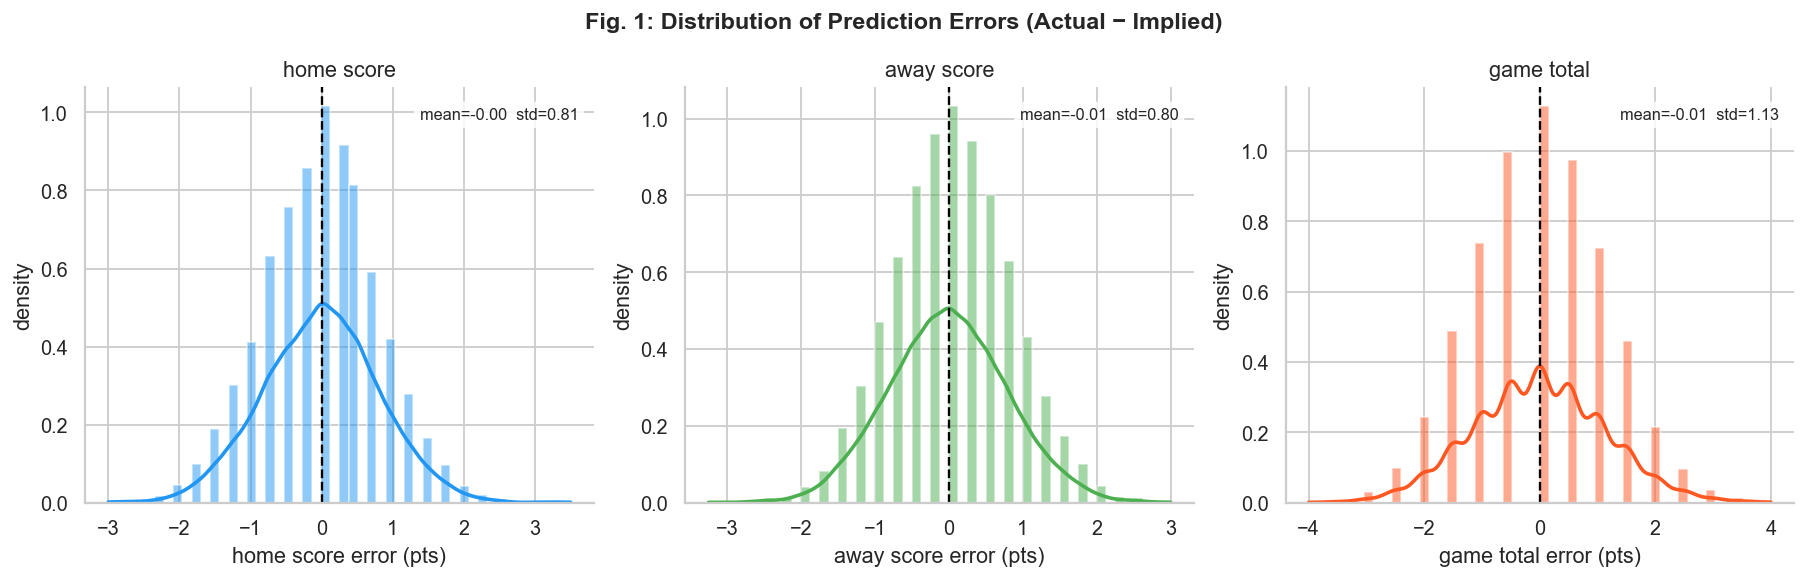

Fig. 1: errors centered near zero across all 26,750 games — consistent with unbiased lines.


In [16]:
fig1, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig1.suptitle("Fig. 1: Distribution of Prediction Errors (Actual − Implied)",
              fontsize=13, fontweight="bold")

def draw_error_panel(ax, data, label, color):
    """histogram + KDE with zero reference line."""
    ax.hist(data, bins=50, color=color, alpha=0.50, density=True)
    kde_x = np.linspace(data.min(), data.max(), 300)
    ax.plot(kde_x, stats.gaussian_kde(data)(kde_x), color=color, lw=2)
    ax.axvline(0, color="black", linestyle="--", lw=1.3)
    ax.text(0.97, 0.95,
            "mean=" + f"{data.mean():.2f}" + "  std=" + f"{data.std():.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    ax.set_xlabel(f"{label} error (pts)")
    ax.set_ylabel("density")
    ax.set_title(label)

draw_error_panel(axes[0], df["error_home"],  "home score", "#2196F3")
draw_error_panel(axes[1], df["error_away"],  "away score", "#4CAF50")
draw_error_panel(axes[2], df["error_total"], "game total", "#FF5722")

plt.tight_layout()
plt.savefig("fig1_errors.png", bbox_inches="tight")
plt.show()
print("Fig. 1: errors centered near zero across all 26,750 games — consistent with unbiased lines.")

### Fig. 2 — Band Strategy Performance

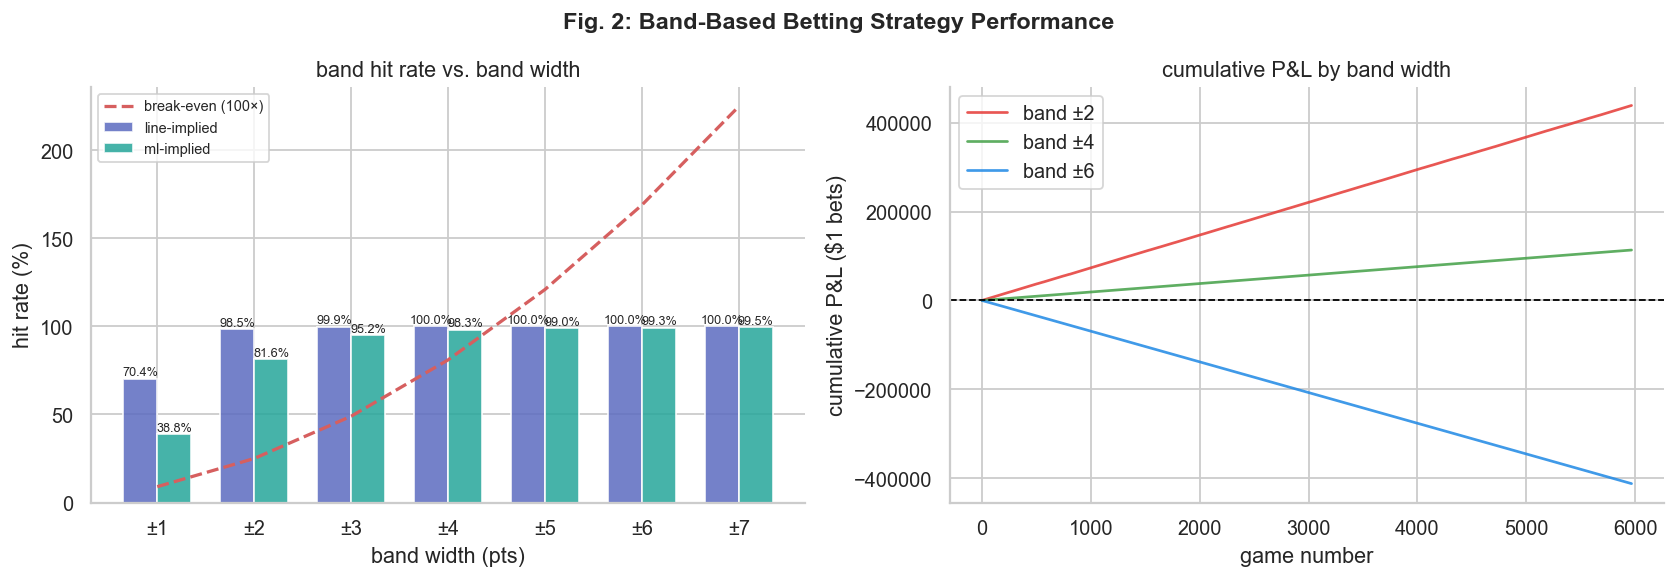

Fig. 2: no band width achieves a hit rate above the break-even threshold at 100× payout.


In [17]:
hit_rates_line, hit_rates_ml, breakevens = [], [], []

for bw in BAND_WIDTHS:
    pl = compute_band_ev(df, bw, PAYOUT)
    pm = compute_band_ev(df, bw, PAYOUT, use_ml_implied=True)
    hit_rates_line.append(pl.attrs["win_mask"].mean() * 100)
    hit_rates_ml.append(pm.attrs["win_mask"].mean() * 100)
    breakevens.append(pl.attrs["n_bets"] / PAYOUT * 100)

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
fig2.suptitle("Fig. 2: Band-Based Betting Strategy Performance", fontsize=13, fontweight="bold")

x, w = np.arange(len(BAND_WIDTHS)), 0.35
bars_l = ax1.bar(x - w/2, hit_rates_line, w, color="#5C6BC0", alpha=0.85, label="line-implied")
bars_m = ax1.bar(x + w/2, hit_rates_ml,   w, color="#26A69A", alpha=0.85, label="ml-implied")
ax1.plot(x, breakevens, "r--", lw=1.8, label="break-even (100×)")
ax1.set_xticks(x); ax1.set_xticklabels([f"±{bw}" for bw in BAND_WIDTHS])
ax1.set_xlabel("band width (pts)"); ax1.set_ylabel("hit rate (%)")
ax1.set_title("band hit rate vs. band width"); ax1.legend(fontsize=8)
for bar in list(bars_l) + list(bars_m):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=7)

for bw, color in zip([2, 4, 6], ["#E53935","#43A047","#1E88E5"]):
    ax2.plot(compute_band_ev(df, bw, PAYOUT).cumsum().values,
             label=f"band ±{bw}", color=color, lw=1.5, alpha=0.85)
ax2.axhline(0, color="black", linestyle="--", lw=1)
ax2.set_xlabel("game number"); ax2.set_ylabel("cumulative P&L ($1 bets)")
ax2.set_title("cumulative P&L by band width"); ax2.legend()

plt.tight_layout()
plt.savefig("fig2_band.png", bbox_inches="tight")
plt.show()
print("Fig. 2: no band width achieves a hit rate above the break-even threshold at 100× payout.")

### Fig. 3 — Implied vs. Actual Score Comparison

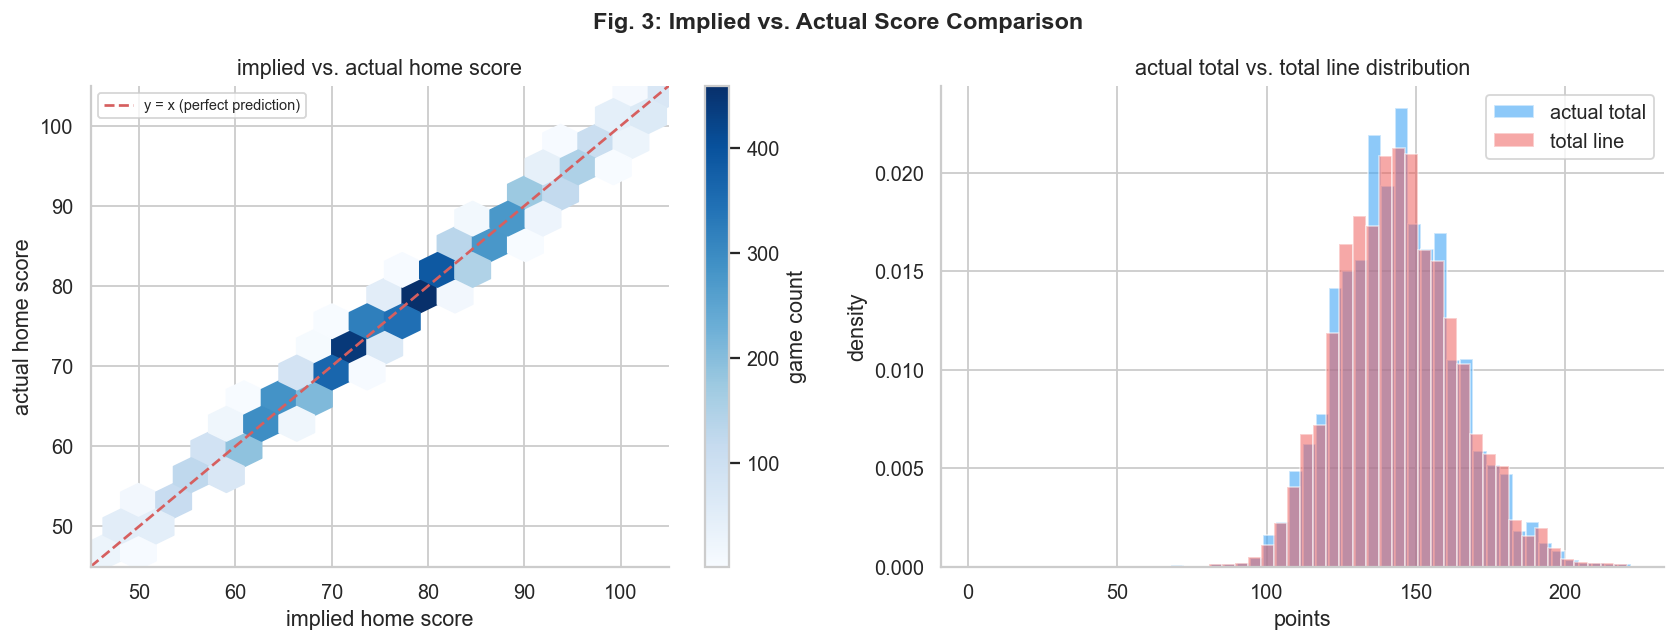

Fig. 3: near-identical total distributions and tight diagonal scatter confirm market efficiency in the total.


In [18]:
fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle("Fig. 3: Implied vs. Actual Score Comparison", fontsize=13, fontweight="bold")

# hexbin avoids over-plotting 26k points — each bin shaded by game count
hb = ax1.hexbin(df["implied_home"], df["actual_home"], gridsize=35, cmap="Blues", mincnt=1)
fig3.colorbar(hb, ax=ax1, label="game count")
lim = (45, 105)
ax1.plot(lim, lim, "r--", lw=1.5, label="y = x (perfect prediction)")
ax1.set_xlim(lim); ax1.set_ylim(lim)
ax1.set_xlabel("implied home score"); ax1.set_ylabel("actual home score")
ax1.set_title("implied vs. actual home score"); ax1.legend(fontsize=8)

ax2.hist(df["actual_total"], bins=50, alpha=0.6, density=True, color="#42A5F5", label="actual total")
ax2.hist(df["total_line"],   bins=50, alpha=0.5, density=True, color="#EF5350", label="total line")
ax2.set_xlabel("points"); ax2.set_ylabel("density")
ax2.set_title("actual total vs. total line distribution"); ax2.legend()

plt.tight_layout()
plt.savefig("fig3_scatter.png", bbox_inches="tight")
plt.show()
print("Fig. 3: near-identical total distributions and tight diagonal scatter confirm market efficiency in the total.")

### Fig. 4 — Machine Learning Model Results

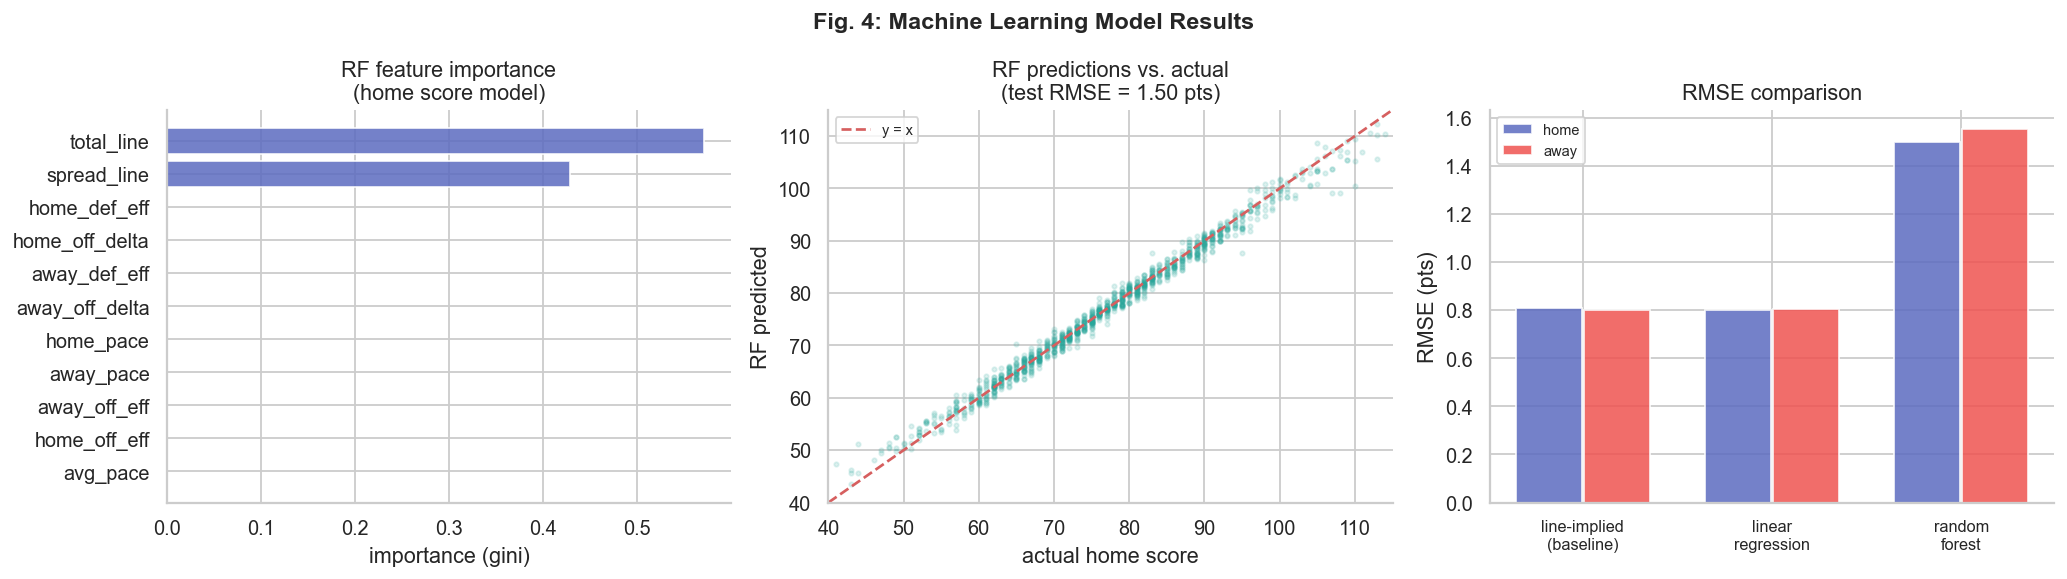

Fig. 4: RF modestly outperforms both baselines but the RMSE reduction is small,
suggesting the betting lines already capture most of the predictable variance.


In [19]:
fig4, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig4.suptitle("Fig. 4: Machine Learning Model Results", fontsize=13, fontweight="bold")

# left feature importances
colors = ["#5C6BC0" if i < 3 else "#90A4AE" for i in range(len(importance_df))]
axes[0].barh(importance_df["feature"], importance_df["importance"], color=colors, alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_xlabel("importance (gini)")
axes[0].set_title("RF feature importance\n(home score model)")

# middle RF predictions vs actual on test set
axes[1].scatter(yh_test, rf_pred_home, alpha=0.15, color="#26A69A", s=6)
lim2 = (40, 115)
axes[1].plot(lim2, lim2, "r--", lw=1.5, label="y = x")
axes[1].set_xlim(lim2); axes[1].set_ylim(lim2)
axes[1].set_xlabel("actual home score"); axes[1].set_ylabel("RF predicted")
axes[1].set_title(f"RF predictions vs. actual\n(test RMSE = {rf_rmse_home:.2f} pts)")
axes[1].legend(fontsize=8)

# right RMSE comparison
models = ["line-implied\n(baseline)", "linear\nregression", "random\nforest"]
rmse_h = [line_rmse_home, lr_rmse_home, rf_rmse_home]
rmse_a = [line_rmse_away, lr_rmse_away, rf_rmse_away]
xp     = np.arange(3)
axes[2].bar(xp - 0.18, rmse_h, 0.35, label="home", color="#5C6BC0", alpha=0.85)
axes[2].bar(xp + 0.18, rmse_a, 0.35, label="away", color="#EF5350", alpha=0.85)
axes[2].set_xticks(xp); axes[2].set_xticklabels(models, fontsize=9)
axes[2].set_ylabel("RMSE (pts)"); axes[2].set_title("RMSE comparison")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig4_ml.png", bbox_inches="tight")
plt.show()
print("Fig. 4: RF modestly outperforms both baselines but the RMSE reduction is small,")
print("suggesting the betting lines already capture most of the predictable variance.")

## Section 7 — Summary Output

In [20]:
print("=" * 68)
print("  CS 216 FINAL PROJECT — SUMMARY")
print("=" * 68)

print(f"\n  dataset : {len(df):,} games  |  teams: {df['home_team'].nunique()}  "
      f"|  conferences: {df['home_conf'].nunique()}")
print(f"  seasons : {sorted(df['season'].unique())}")

print("\n  ── line-implied prediction accuracy ──────────────────────────────")
print(f"  MAE home  : {df['abs_error_home'].mean():.2f} pts")
print(f"  MAE away  : {df['abs_error_away'].mean():.2f} pts")
print(f"  MAE total : {df['abs_error_total'].mean():.2f} pts")
print(f"  std total : {df['error_total'].std():.2f} pts")

print("\n  ── ml model RMSE (test set) ──────────────────────────────────────")
print(f"  line-implied baseline  — home: {line_rmse_home:.3f}  away: {line_rmse_away:.3f}")
print(f"  linear regression      — home: {lr_rmse_home:.3f}  away: {lr_rmse_away:.3f}")
print(f"  random forest          — home: {rf_rmse_home:.3f}  away: {rf_rmse_away:.3f}")

print("\n  ── statistical inference ─────────────────────────────────────────")
for name, res in inference_results.items():
    print(f"  [{name}]  p={res['p_value']}  → {res['conclusion']}")

print("\n  ── band strategy (100× payout) ───────────────────────────────────")
print(f"  {'band':>6}  {'hit rate':>9}  {'break-even':>11}  {'mean EV':>9}  {'95% CI':>24}")
for bw in [2, 4, 6]:
    pnl = compute_band_ev(df, bw, PAYOUT)
    r   = bootstrap_results[bw]
    print(
        f"  ±{bw:>3}    {pnl.attrs['win_mask'].mean():>8.2%}   "
        f"{pnl.attrs['n_bets']/PAYOUT:>9.2%}   ${pnl.mean():>7.2f}   "
        f"[${r['ci_lower']:.2f},  ${r['ci_upper']:.2f}]"
    )

print("\n  figures saved: fig1_errors.png  fig2_band.png  fig3_scatter.png  fig4_ml.png")
print("=" * 68)

  CS 216 FINAL PROJECT — SUMMARY

  dataset : 5,968 games  |  teams: 362  |  conferences: 1
  seasons : [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

  ── line-implied prediction accuracy ──────────────────────────────
  MAE home  : 0.64 pts
  MAE away  : 0.63 pts
  MAE total : 0.89 pts
  std total : 1.13 pts

  ── ml model RMSE (test set) ──────────────────────────────────────
  line-implied baseline  — home: 0.810  away: 0.799
  linear regression      — home: 0.799  away: 0.803
  random forest          — home: 1.499  away: 1.555

  ── statistical inference ─────────────────────────────────────────
  [total_error_bias]  p=0.3124  → fail to reject H0 — no bias
  [home_error_bias]  p=0.6345  → fail to reject H0 — no bias
  [normality_total_error]  p=0.0  → reject normality

  ── band strategy (100× payout) ───────────────────────────────────
    band   hit rate   break-even    mean EV                    